# Visualize and Calculate some PEDSIM stats

In [1]:
import numpy as np
import os as os
import sys as sys
import multiprocessing as mp
import pandas as pd
import socket
import matplotlib.pyplot as plt

### Do the Arial 
from matplotlib import rcParams
rcParams['font.family'] = 'sans-serif'   # Set the default
rcParams['font.sans-serif'] = ['Arial']  # Make sure to have the font installed (it is on cluster for Harald)

### Pick the right path (whether on cluster or at home)
socket_name = socket.gethostname()
print(socket_name)

if socket_name.startswith("bionc") or socket_name.startswith("hpc"):
    print("Leipzig Cluster detected!")
    path = "/mnt/archgen/users/hringbauer/git/EPIDEMIC/"
    #sys.path.append("/mnt/archgen/users/hringbauer/git/hapBLOCK/python3/")
    #sys.path.insert(0, "/mnt/archgen/users/hringbauer/git/hapBLOCK/package/")
else: 
    raise RuntimeWarning("Not compatible machine. Check!!")
    
os.chdir(path)  # Set the right Path (in line with Atom default)
sys.path.append("./package/")  # Go to the hapsburg package directory

print(os.getcwd()) # Show the current working directory. Should be HAPSBURG/Notebooks/ParallelRuns
print(f"CPU Count: {mp.cpu_count()}")

hpc030
Leipzig Cluster detected!
/mnt/archgen/users/hringbauer/git/EPIDEMIC
CPU Count: 128


# 0) Load Data
And check whether it worked via scatter plot of IBD

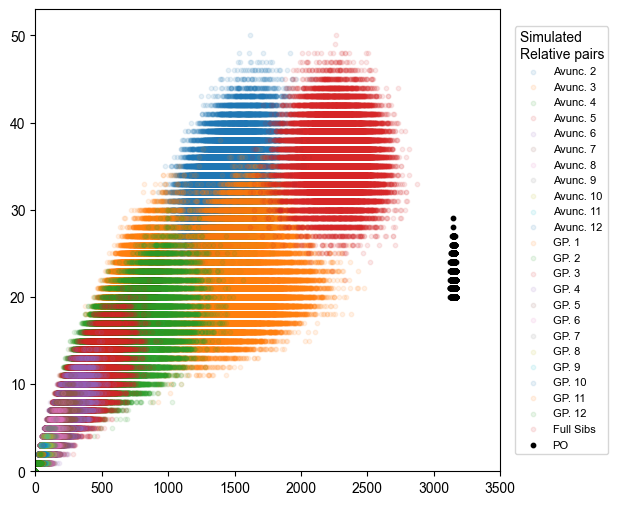

CPU times: user 1.99 s, sys: 319 ms, total: 2.31 s
Wall time: 2.99 s


In [2]:
%%time 

avs = [f"/mnt/archgen/users/hringbauer/output/pedsim/ben50kgap1break/av{i}.tsv" for i in range(2,13)]
dfts = [pd.read_csv(p, sep="\t") for p in avs]
labels = [f"Avunc. {d}" for d in range(2,13)]

gps = [f"/mnt/archgen/users/hringbauer/output/pedsim/ben50kgap1break/gp{i}.tsv" for i in range(1,13)]
dfts2 = [pd.read_csv(p, sep="\t") for p in gps]
labels2 = [f"GP. {d}" for d in range(1,13)]

dffs = pd.read_csv("/mnt/archgen/users/hringbauer/output/pedsim/ben50kgap1break/fs.tsv", sep="\t") 
dfpo = pd.read_csv("/mnt/archgen/users/hringbauer/output/pedsim/ben50kgap1break/po.tsv", sep="\t") 

plt.figure(figsize=(6,6))
ax = plt.gca()

for dft,l in zip(dfts,labels):
    ax.scatter(dft["sum_IBD>12"], dft["n_IBD>12"], label=l, alpha=0.1, s=10)

for dft,l in zip(dfts2,labels2):
    ax.scatter(dft["sum_IBD>12"], dft["n_IBD>12"], label=l, alpha=0.1, s=10)

ax.scatter(dffs["sum_IBD>12"], dffs["n_IBD>12"], label="Full Sibs", alpha=0.1, s=10)
ax.scatter(dfpo["sum_IBD>12"], dfpo["n_IBD>12"], label="PO", alpha=1, s=10, color="k")

ax.set_xlim([0,3500])
ax.set_ylim([0,53])
ax.legend(loc="center left", title="Simulated \nRelative pairs", fontsize=8, bbox_to_anchor=(1.02, 0.5))
plt.show()

# Ask how often single IBD of some length is shared

In [59]:
def get_ibd_cts_lgts(df, n_ibd=1, cm=30, cm_tol=3):
    """Give sub dataframe of all IBD pairs with given number and max length of IBD
    cm_tol: hom many cm one can be off
    cm: length of the longest IBD
    n_ibd: number of IBD segments"""    
    idx_nIBD = df["n_IBD>8"]==n_ibd
    idx_maxIBD = np.isclose(df["max_IBD"], cm, atol=cm_tol)
    idx = idx_nIBD & idx_maxIBD
    return df[idx]

In [70]:
n = 5e4
ks = np.zeros(len(dfts), dtype="int")

for i in range(len(dfts)):
    dfx = dfts[i]
    l = labels[i]
    
    dft = get_ibd_cts_lgts(dfx, n_ibd=1, cm=80, cm_tol=5)
    print(l)
    print(len(dft))
    ks[i] = len(dft)

Avunc. 2
0
Avunc. 3
0
Avunc. 4
0
Avunc. 5
3
Avunc. 6
10
Avunc. 7
14
Avunc. 8
10
Avunc. 9
5
Avunc. 10
0
Avunc. 11
0
Avunc. 12
0


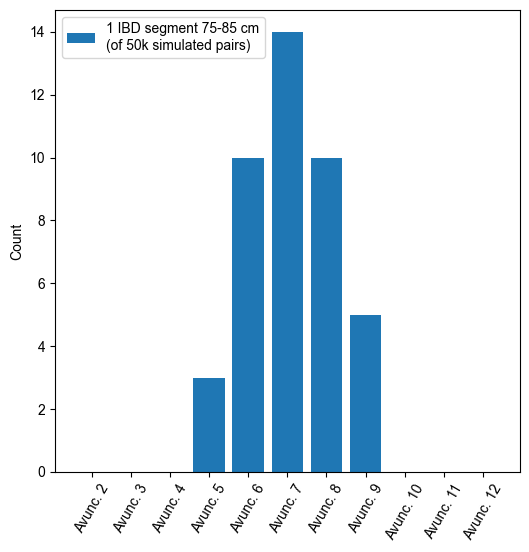

In [71]:
plt.figure(figsize=(6,6))
ax = plt.gca()

xs = np.arange(len(ks))
ax.bar(xs, ks, label="1 IBD segment 75-85 cm\n(of 50k simulated pairs)")
ax.set_xticks(xs)
ax.set_xticklabels(labels, rotation=60)
ax.set_ylabel("Count")
ax.legend(loc="upper left")
plt.show()